In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

### Dataset:
Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

Source: Data Source :http://data.seoul.go.kr/
SOUTH KOREA PUBLIC HOLIDAYS. URL: publicholidays.go.kr

In [2]:
# Load the dataset
url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/main/Python/projects/bike_sharing/data/SeoulBikeData.csv"
df = pd.read_csv(url, encoding="latin1")

In [3]:
# Rename columns using a dictionary
column_mapping = {
	"Rented Bike Count": "bike_count",
	"Temperature(°C)": "temp",
	"Humidity(%)": "humidity",
	"Wind speed (m/s)": "wind",
	"Visibility (10m)": "visibility",
	"Dew point temperature(°C)": "dew_pt_temp",
	"Solar Radiation (MJ/m2)": "radiation",
	"Rainfall(mm)": "rain",
	"Snowfall (cm)": "snow",
	"Functioning Day": "functional",
}
df = df.rename(columns=column_mapping)

In [4]:
# Drop unnecessary columns
columns_to_drop = ["Date", "Holiday", "Seasons", "Hour"]

# Convert functional column and filter for hour 12
df = (
	df.assign(functional=(df["functional"] == "Yes").astype(int))
	.query("Hour == 12")
	.rename(columns=column_mapping)
	.drop(columns_to_drop, axis=1)
)

In [5]:
df.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


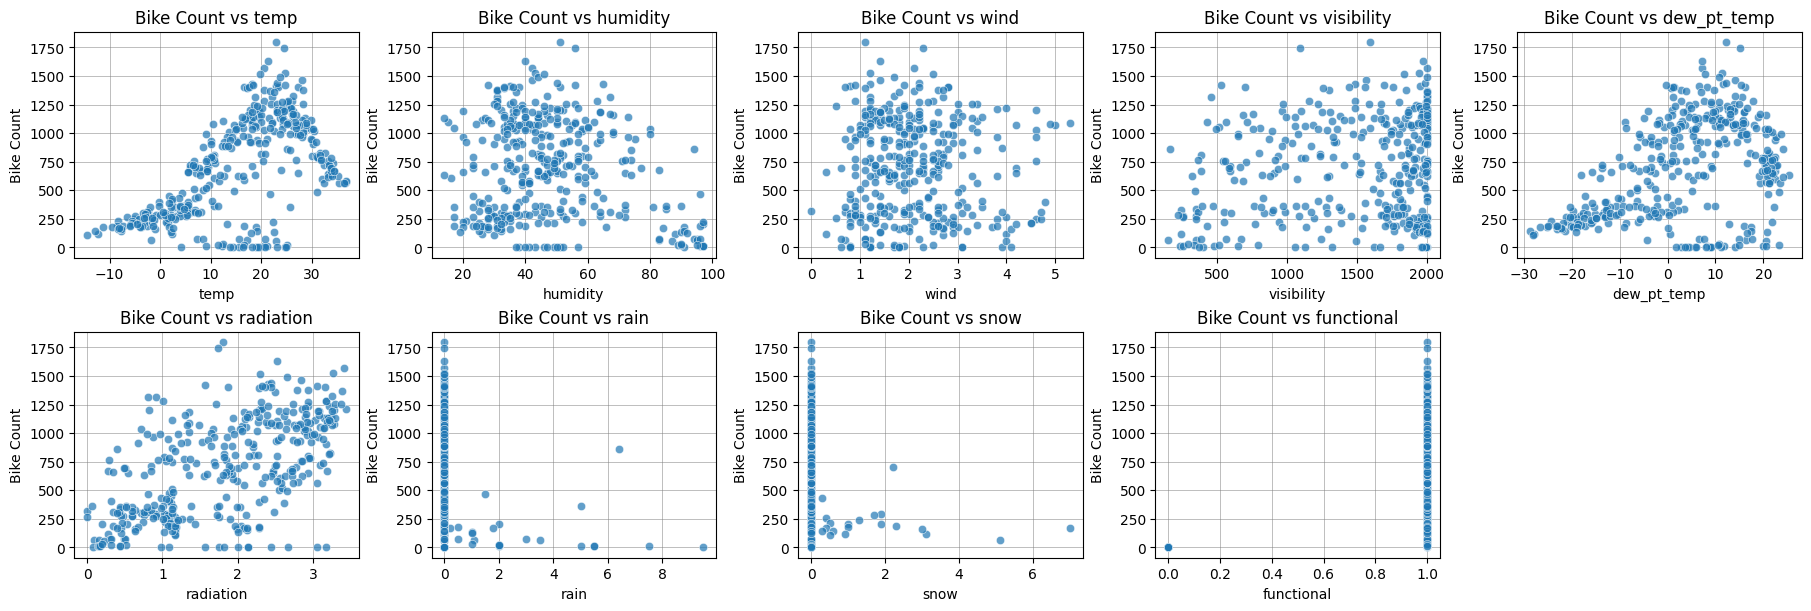

In [6]:
cols = df.columns.to_list()

feature_names = cols[1:]
num_features = len(feature_names)

fig, axes = plt.subplots(2, 5, figsize=(18, 6), constrained_layout=True)
axes = axes.ravel()

for axis, feature in zip(axes, feature_names):
	sns.scatterplot(
		data=df,
		x=feature,
		y="bike_count",
		alpha=0.7,
		ax=axis,
	)
	axis.set_title(f"Bike Count vs {feature}")
	axis.set_xlabel(feature)
	axis.set_ylabel("Bike Count")
	axis.grid(True, alpha=0.6, linewidth=0.6, color="grey")
	axis.set_axisbelow(True)

# Hide any unused subplots
for i in range(len(feature_names), len(axes)):
	axes[i].set_visible(False)

plt.show()

In [7]:
df = df.drop(["wind", "visibility", "functional"], axis=1)

In [8]:
df.head()

,bike_count,temp,humidity,dew_pt_temp,radiation,rain,snow
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


## Train, validation, test datasets

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def prepare_datasets(
	dataframe: pd.DataFrame,
	target: str,
	random_state: int = 42,
	test_size: float = 0.2,
	val_size: float = 0.2,
	scale_target: bool = False,
	scale_features: bool = True,
) -> tuple:
	"""
	Split, scale, and prepare dataset into train, validation, and test sets.

	This function follows the standard split principle for machine learning
	datasets, ensuring proper data separation for model training and evaluation.

	Parameters
	----------
	dataframe : pd.DataFrame
		Input dataframe containing features and target variable
	target : str
		Name of the target column to predict
	random_state : int, default=42
		Random state for reproducible splits
	test_size : float, default=0.2
		Proportion of dataset to allocate for testing
	val_size : float, default=0.2
		Proportion of dataset to allocate for validation
	scale_target : bool, default=False
		Whether to scale the target variable (useful for regression models)
	scale_features : bool, default=True
		Whether to scale the feature variables using StandardScaler

	Returns
	-------
	tuple
		Three tuples containing (features, target) for train, validation, and test sets
		along with individual components for flexibility. Features are scaled if scale_features=True,
		otherwise they are the original values as numpy arrays.

	Raises
	------
	ValueError
		If target column doesn't exist, dataframe is empty, or split sizes are invalid
	KeyError
		If target column is not found in dataframe

	Notes
	-----
	- Uses StandardScaler for feature normalization (z-score standardization) if scale_features=True
	- Scaler is fit ONLY on training data to prevent data leakage
	- Validation set helps with hyperparameter tuning and early stopping
	"""
	# Input validation
	if dataframe.empty:
		raise ValueError("DataFrame is empty")

	if target not in dataframe.columns:
		raise KeyError(
			f"Target column '{target}' not found in DataFrame columns: {list(dataframe.columns)}"
		)

	if not (0 < test_size < 1) or not (0 < val_size < 1):
		raise ValueError("test_size and val_size must be between 0 and 1")

	if test_size + val_size >= 1:
		raise ValueError("test_size + val_size must be less than 1")

	# Separate features (X) from target (y)
	X = dataframe.drop(target, axis=1).copy()
	y = dataframe[target].copy()

	temp_size = test_size + val_size

	# First split: train vs temporary (validation + test)
	X_train, X_temp, y_train, y_temp = train_test_split(
		X,
		y,
		test_size=temp_size,
		random_state=random_state,
		stratify=None,
	)

	# Second split: split temporary set into validation and test
	val_proportion = val_size / temp_size
	X_val, X_test, y_val, y_test = train_test_split(
		X_temp, y_temp, test_size=(1 - val_proportion), random_state=random_state
	)

	# Feature scaling - fit ONLY on training data to prevent data leakage if scale_features=True
	if scale_features:
		feature_scaler = StandardScaler()
		X_train_scaled = feature_scaler.fit_transform(X_train)
		X_val_scaled = feature_scaler.transform(X_val)
		X_test_scaled = feature_scaler.transform(X_test)
	else:
		X_train_scaled = X_train.values
		X_val_scaled = X_val.values
		X_test_scaled = X_test.values

	# Optional target scaling for regression models
	if scale_target:
		target_scaler = StandardScaler()
		y_train_scaled = target_scaler.fit_transform(
			y_train.values.reshape(-1, 1)
		).flatten()
		y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
		y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()
	else:
		y_train_scaled, y_val_scaled, y_test_scaled = y_train, y_val, y_test

	# Package data with conventional naming (val instead of valid)
	train = (X_train_scaled, y_train_scaled)
	val = (X_val_scaled, y_val_scaled)
	test = (X_test_scaled, y_test_scaled)

	# Return both packaged tuples and individual components for flexibility
	return (
		(train, X_train_scaled, y_train_scaled),
		(val, X_val_scaled, y_val_scaled),
		(test, X_test_scaled, y_test_scaled),
	)

In [10]:
(train, X_train, y_train), (val, X_val, y_val), (test, X_test, y_test) = (
	prepare_datasets(
		dataframe=df,
		target="bike_count",
		random_state=42,
		test_size=0.2,
		val_size=0.2,
		scale_target=False,
		scale_features=False,
	)
)

## Linear Regression

The linear regression model follows the equation:

$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n + \epsilon$$

Where:
- $y$ is the dependent variable (target)
- $\beta_0$ is the intercept (bias term)
- $\beta_1, \beta_2, \ldots, \beta_n$ are the coefficients for each feature
- $x_1, x_2, \ldots, x_n$ are the independent variables (features)
- $\epsilon$ is the error term

In [11]:
from sklearn.linear_model import LinearRegression

In [ ]:
feature_col = ["temp"]
target_col = "bike_count"
X_train_temp = X_train[feature_col].values
y_train_temp = 


In [12]:
# Fit a univariate linear regression on temperature only
temp_only_reg = LinearRegression()
temp_only_reg.fit(X_train[:, 0].reshape(-1, 1), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


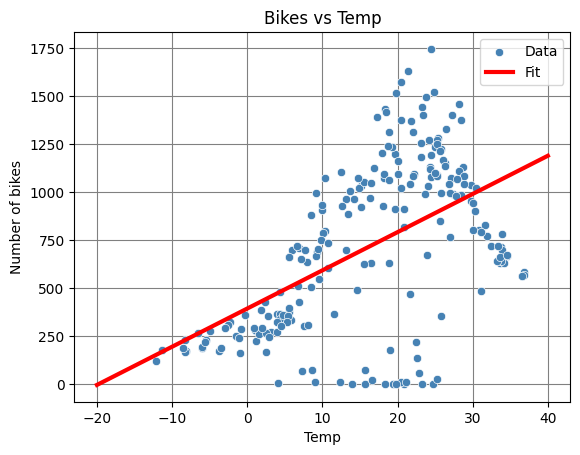

In [13]:
# Scatter plot of temperature vs bike count using Seaborn
plt.figure()
sns.scatterplot(x=X_train[:, 0], y=y_train, label="Data", color="steelblue")

# Generate x values for the regression line
x = tf.linspace(-20, 40, 100)

# Plot the regression line using Seaborn
sns.lineplot(
	x=x.numpy(),
	y=temp_only_reg.predict(x.numpy().reshape(-1, 1)),
	label="Fit",
	color="red",
	linewidth=3,
)
plt.legend()
plt.grid(True, color="grey")
plt.gca().set_axisbelow(True)
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

In [ ]:
temp_only_reg.score(X_test, y_test)

# Multiple Linear Regression 
The multiple linear regression model extends the simple linear regression to include multiple predictors:

$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n + \epsilon$$

Where:
- $y$ is the dependent variable (target)
- $\beta_0$ is the intercept (bias term)
- $\beta_1, \beta_2, \ldots, \beta_n$ are the coefficients for each feature
- $x_1, x_2, \ldots, x_n$ are the independent variables (features)
- $\epsilon$ is the error term

In matrix form, this can be expressed as:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

Where:
- $\mathbf{y}$ is the vector of observed values
- $\mathbf{X}$ is the design matrix containing the features
- $\boldsymbol{\beta}$ is the vector of coefficients
- $\boldsymbol{\epsilon}$ is the vector of error terms